In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from pathlib import Path

TICKERS = [
    "AI.PA", "AIR.PA", "ACA.PA", "CS.PA", "BNP.PA", "EN.PA", "CAP.PA",
    "CA.PA", "BN.PA", "DSY.PA", "EL.PA", "ENGI.PA", "RMS.PA", "KER.PA",
    "LR.PA", "OR.PA", "MC.PA", "ML.PA", "ORA.PA", "RI.PA", "PUB.PA",
    "RNO.PA", "SAF.PA", "SGO.PA", "SAN.PA", "SU.PA", "GLE.PA", "HO.PA",
    "TTE.PA", "VIE.PA",
]

prices = yf.download(
    TICKERS,
    start="2016-08-01",
    end="2026-08-01",
    auto_adjust=True,
    progress=False,
)["Close"]

print(prices.shape)
print(prices.isna().sum().sort_values(ascending=False).head(10))

(2561, 30)
Ticker
ACA.PA    0
AI.PA     0
TTE.PA    0
SU.PA     0
SGO.PA    0
SAN.PA    0
SAF.PA    0
RNO.PA    0
RMS.PA    0
RI.PA     0
dtype: int64


In [2]:
seuil = int(0.99 * len(prices))
prices = prices.dropna(axis=1, thresh=seuil)   # jette les valeurs trop trouées
prices = prices.dropna()                        # jette les jours incomplets restants

Path("data").mkdir(exist_ok=True)
prices.to_csv("data/prices.csv")

print(prices.shape, prices.index.min().date(), prices.index.max().date())

(2561, 30) 2016-08-01 2026-07-31


Matplotlib is building the font cache; this may take a moment.


(2560, 30)


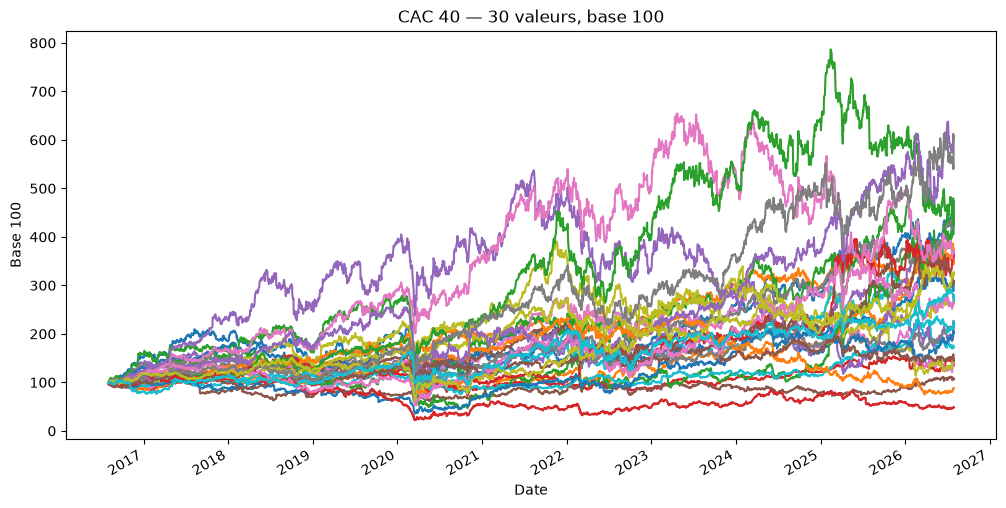

In [3]:
import matplotlib.pyplot as plt

returns = np.log(prices / prices.shift(1)).dropna()
print(returns.shape)

(prices / prices.iloc[0] * 100).plot(figsize=(12, 6), legend=False)
plt.title("CAC 40 — 30 valeurs, base 100")
plt.ylabel("Base 100")
plt.show()